#  Research Questions & Initial EDA
## Comeback Analytics — Gaussian Process Regression on Shot Quality Trajectories

**Objective:** Define research hypotheses, load MoneyPuck data, and explore shot quality patterns in third-period comeback situations.

**Expected outputs:**
- Cleaned dataset filtered to comeback situations (down by 2, 3rd period)
- EDA plots (raw shot counts, xGoal distributions by time window)
- Summary statistics and data validation checks


## 1. Research Framework

### Research Question
**Do teams trailing by two goals in the third period exhibit increasing shot quality (expected goals) over time as they mount a comeback attempt?**

### Hypotheses

**H1 (Primary):** Shot quality (xGoal per shot) increases monotonically in comeback situations as teams shift from deficit-management to offensive pressure.

**H2 (Secondary):** Shot volume increases along with quality—teams may increase both the quantity and intensity of scoring chances.

**H3 (Mechanism):** The effect is driven by player positioning and shot selection changes, not by lucky/unlucky variation or random noise.

### Key Construct: Comeback Situation
- **Definition:** Third period, trailing by exactly 2 goals (or 3 for robustness checks)
- **Rationale:** Down 2 is "comeback-feasible" (within reach in 20 minutes); down 3+ is less actionable
- **Temporal binning:** Four 5-minute windows (0–5, 5–10, 10–15, 15–20 min of period)
- **Data source:** MoneyPuck 2014-2015 to 2024-2025 seasons, all teams, 5-on-5 situations

### Statistical Framework
- **Response variable:** xGoal per shot (continuous)
- **Predictor:** Time elapsed in period (continuous, 0–1200 seconds)
- **Smoothness assumption:** Shot quality follows a smooth trajectory (justifies GP regression with Matérn kernel)
- **Uncertainty quantification:** Credible bands around posterior mean


## 2. Data Pipeline Setup


In [3]:
#%pip install pandas numpy matplotlib seaborn pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Define paths

# Find project root dynamically
ROOT = Path().resolve()
while not (ROOT / "src").exists():
    ROOT = ROOT.parent

sys.path.append(str(ROOT))

from src.paths import MODELS_DIR, RESULTS_DIR, DATA_DIR

print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {RESULTS_DIR}")

Data directory: /Users/adriana-stefaniaciupeanu/Documents/GP_regression_Hockey/data
Output directory: /Users/adriana-stefaniaciupeanu/Documents/GP_regression_Hockey/Results


### 2.1 Load Raw Data


In [4]:
# load the data
files = {
    '2014': f'{DATA_DIR}/shots_2014.csv',
    '2015': f'{DATA_DIR}/shots_2015.csv',
    '2016': f'{DATA_DIR}/shots_2016.csv',
    '2017': f'{DATA_DIR}/shots_2017.csv',
    '2018': f'{DATA_DIR}/shots_2018.csv',
    '2019': f'{DATA_DIR}/shots_2019.csv',
    '2020': f'{DATA_DIR}/shots_2020.csv',  # COVID-shortened
    '2021': f'{DATA_DIR}/shots_2021.csv',  # COVID-shortened
    '2022': f'{DATA_DIR}/shots_2022.csv',
    '2023': f'{DATA_DIR}/shots_2023.csv',
    '2024': f'{DATA_DIR}/shots_2024.csv',
}

# Load and concatenate all seasons
dfs = []
for season, filepath in files.items():
    try:
        df = pd.read_csv(filepath)
        df['season'] = int(season)
        dfs.append(df)
        print(f"✓ {season}: {len(df):,} shots loaded")
    except FileNotFoundError:
        print(f"✗ {season}: File not found at {filepath}")

shots_df = pd.concat(dfs, ignore_index=True)
print(f"\n" + "="*60)
print(f"Total raw shots dataset: {shots_df.shape}")
print(f"Seasons covered: {sorted(shots_df['season'].unique())}")
print(f"Columns: {shots_df.columns.tolist()}")
print(f"="*60)
print(f"\nFirst few rows:")
shots_df.head(10)

✓ 2014: 109,627 shots loaded
✓ 2015: 109,461 shots loaded
✓ 2016: 110,953 shots loaded
✓ 2017: 119,715 shots loaded
✓ 2018: 117,622 shots loaded
✓ 2019: 104,172 shots loaded
✓ 2020: 78,611 shots loaded
✓ 2021: 121,471 shots loaded
✓ 2022: 122,026 shots loaded
✓ 2023: 122,472 shots loaded
✓ 2024: 119,870 shots loaded

Total raw shots dataset: (1236000, 137)
Seasons covered: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Columns: ['shotID', 'homeTeamCode', 'awayTeamCode', 'season', 'isPlayoffGame', 'game_id', 'homeTeamWon', 'id', 'time', 'timeUntilNextEvent', 'timeSinceLastEvent', 'period', 'team', 'location', 'event', 'goal', 'shotPlayContinuedOutsideZone', 'shotPlayContinuedInZone', 'shotGoalieFroze', 'shotPlayStopped', 'shotGeneratedRebound', 'homeTeamGoals', 'awayTeamGoals', 'xCord', 'yCord', 'xCordAdjusted', 'yCordAdjusted', 'shotAngle', 'shotAngleAdjuste

,shotID,homeTeamCode,awayTeamCode,season,isPlayoffGame,game_id,homeTeamWon,id,time,timeUntilNextEvent,...,penaltyLength,playoffGame,roadTeamCode,roadTeamScore,shotGoalProbability,shotPlayContinued,timeBetweenEvents,timeLeft,wentToOT,wentToShootout
0,724088,TOR,MTL,2014,0,20001,0,3,19,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,724089,TOR,MTL,2014,0,20001,0,5,47,9.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,724090,TOR,MTL,2014,0,20001,0,10,85,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,724091,TOR,MTL,2014,0,20001,0,11,93,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,724092,TOR,MTL,2014,0,20001,0,18,132,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,724093,TOR,MTL,2014,0,20001,0,19,150,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,724094,TOR,MTL,2014,0,20001,0,26,191,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,724095,TOR,MTL,2014,0,20001,0,30,205,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,724096,TOR,MTL,2014,0,20001,0,37,266,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,724097,TOR,MTL,2014,0,20001,0,39,282,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.2 Data Cleaning & Filtering


In [5]:
# Ensure data types
shots_df['game_id'] = shots_df['game_id'].astype(str)
shots_df['period'] = shots_df['period'].astype(int)
shots_df['time'] = pd.to_numeric(shots_df['time'], errors='coerce')
shots_df['xGoal'] = pd.to_numeric(shots_df['xGoal'], errors='coerce')
shots_df['homeTeamGoals'] = pd.to_numeric(shots_df['homeTeamGoals'], errors='coerce')
shots_df['awayTeamGoals'] = pd.to_numeric(shots_df['awayTeamGoals'], errors='coerce')


# Remove rows with missing critical values
initial_count = len(shots_df)
shots_df = shots_df.dropna(subset=['game_id', 'period', 'time', 'xGoal', 'homeTeamGoals', 'awayTeamGoals'])
print(f"Removed {initial_count - len(shots_df)} rows with missing values")

# Filter to 3rd period only
shots_3p = shots_df[shots_df['period'] == 3].copy()
print(f"\n3rd period shots: {len(shots_3p)}")

# Calculate score differential for each shot
# (score at the time of the shot from the shooting team's perspective)
shots_3p['score_diff'] = shots_3p.apply(
    lambda row: row['homeTeamGoals'] - row['awayTeamGoals'] if row['team'] == 'H' else row['awayTeamGoals'] - row['homeTeamGoals'],
    axis=1
)

print(f"\nScore differential distribution (3rd period):")
print(shots_3p['score_diff'].value_counts().sort_index())

Removed 0 rows with missing values

3rd period shots: 394153

Score differential distribution (3rd period):
score_diff
-10       11
-9        55
-8       123
-7       577
-6      2121
-5      5561
-4     13862
-3     28163
-2     48945
-1     70622
 0     79664
 1     66351
 2     42325
 3     21610
 4      9791
 5      3204
 6       927
 7       173
 8        35
 9        22
 10       11
Name: count, dtype: int64


### 2.3 Filter to Comeback Situations


In [6]:

# Step 1: Comeback situations (down 2)
comeback_situations = shots_3p[shots_3p['score_diff'] == -2].copy()
print(f"Shots in comeback situations: {len(comeback_situations):,}")

# Step 2: Remove empty-net shots
comeback_df = comeback_situations[~comeback_situations['shotOnEmptyNet'].astype(bool)].copy()
print(f"After removing empty net: {len(comeback_df):,}")

# Step 3: CONVERT TIME to period-elapsed seconds
PERIOD_3_START = 2400  # 3rd period begins at 2400 absolute seconds
comeback_df['time_elapsed_in_period'] = comeback_df['time'] - PERIOD_3_START

# Step 4: Create 5-minute bins for EDA
bin_edges = [0, 300, 600, 900, 1200]
bin_labels = ['0–5 min', '5–10 min', '10–15 min', '15–20 min']
comeback_df['time_bin'] = pd.cut(
    comeback_df['time_elapsed_in_period'],
    bins=bin_edges,
    labels=bin_labels,
    right=False
)

print(f"\nFinal dataset: {len(comeback_df):,} shots")
print(f"Shots by window:\n{comeback_df['time_bin'].value_counts().sort_index()}")

Shots in comeback situations: 48,945
After removing empty net: 47,046

Final dataset: 47,046 shots
Shots by window:
time_bin
0–5 min      12006
5–10 min     12584
10–15 min    11892
15–20 min    10557
Name: count, dtype: int64


## 3. Exploratory Data Analysis


### 3.1 Temporal Distribution of Shots


Shot counts by time window:
time_bin
0–5 min      12006
5–10 min     12584
10–15 min    11892
15–20 min    10557
Name: count, dtype: int64


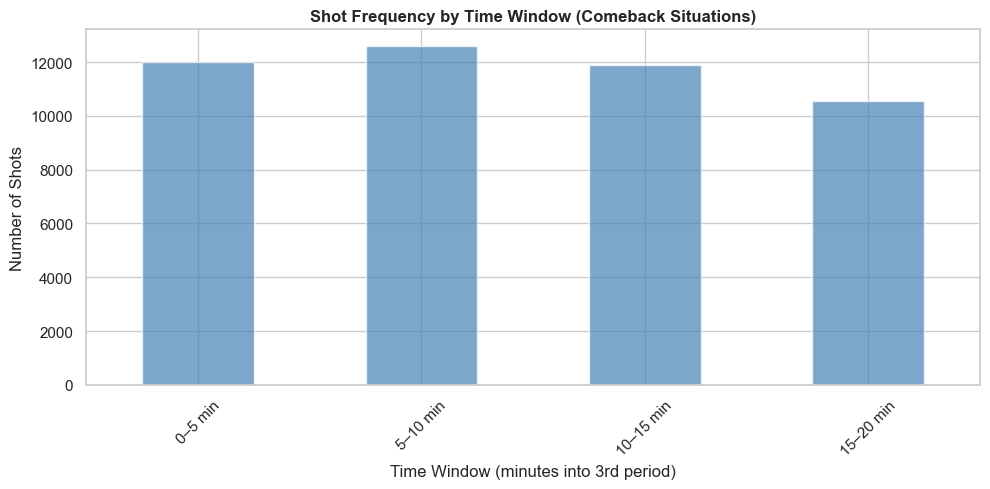


Plot saved to /Users/adriana-stefaniaciupeanu/Documents/GP_regression_Hockey/Results


In [7]:
# Define 5-minute bins (based on period-elapsed time: 0–1200 seconds)
bin_edges = [0, 300, 600, 900, 1200]
bin_labels = ['0–5 min', '5–10 min', '10–15 min', '15–20 min']

# IMPORTANT: Use 'time_elapsed_in_period', NOT 'time'
comeback_df['time_bin'] = pd.cut(
    comeback_df['time_elapsed_in_period'],  # ← CONVERTED TIME
    bins=bin_edges, 
    labels=bin_labels, 
    right=False
)

# Count shots per bin
shot_counts = comeback_df['time_bin'].value_counts().sort_index()
print("Shot counts by time window:")
print(shot_counts)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
shot_counts.plot(kind='bar', ax=ax, color='steelblue', alpha=0.7)
ax.set_title('Shot Frequency by Time Window (Comeback Situations)', fontsize=12, fontweight='bold')
ax.set_xlabel('Time Window (minutes into 3rd period)')
ax.set_ylabel('Number of Shots')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.savefig(RESULTS_DIR / '01_shot_counts_by_window.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nPlot saved to {RESULTS_DIR}")

### 3.2 xGoal Distribution & Summary Statistics


xGoal Summary Statistics (All Comeback Shots):
count    47046.000000
mean         0.071604
std          0.099115
min          0.001000
25%          0.014862
50%          0.037553
75%          0.086274
max          0.962655
Name: xGoal, dtype: float64

xGoal Mean by Time Window:
           count      mean       std    median
time_bin                                      
0–5 min    12006  0.064046  0.087778  0.032570
5–10 min   12584  0.065962  0.089130  0.034199
10–15 min  11892  0.065337  0.091163  0.033839
15–20 min  10557  0.094007  0.124650  0.052027


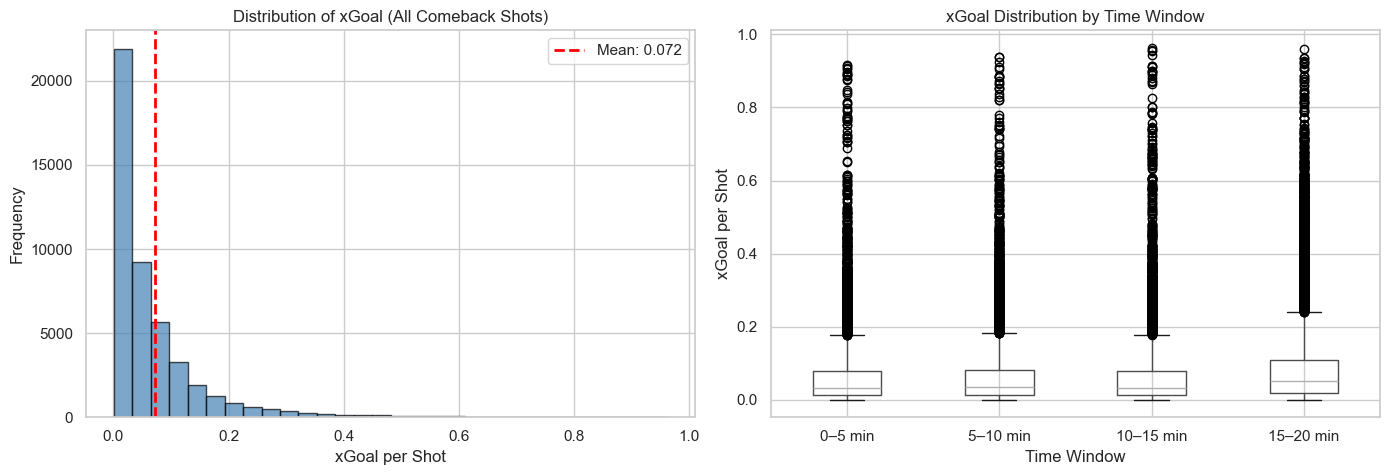

In [8]:
# Summary statistics
print("xGoal Summary Statistics (All Comeback Shots):")
print(comeback_df['xGoal'].describe())

# By time bin
print("\nxGoal Mean by Time Window:")
mean_xgoal_by_bin = comeback_df.groupby('time_bin')['xGoal'].agg(['count', 'mean', 'std', 'median'])
print(mean_xgoal_by_bin)

# Visualize distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(comeback_df['xGoal'], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('xGoal per Shot')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of xGoal (All Comeback Shots)')
axes[0].axvline(comeback_df['xGoal'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {comeback_df["xGoal"].mean():.3f}')
axes[0].legend()

# Box plot by time bin
comeback_df.boxplot(column='xGoal', by='time_bin', ax=axes[1])
axes[1].set_title('xGoal Distribution by Time Window')
axes[1].set_xlabel('Time Window')
axes[1].set_ylabel('xGoal per Shot')
plt.suptitle('')  # Remove automatic title

plt.tight_layout()
plt.savefig(RESULTS_DIR/ '02_xgoal_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

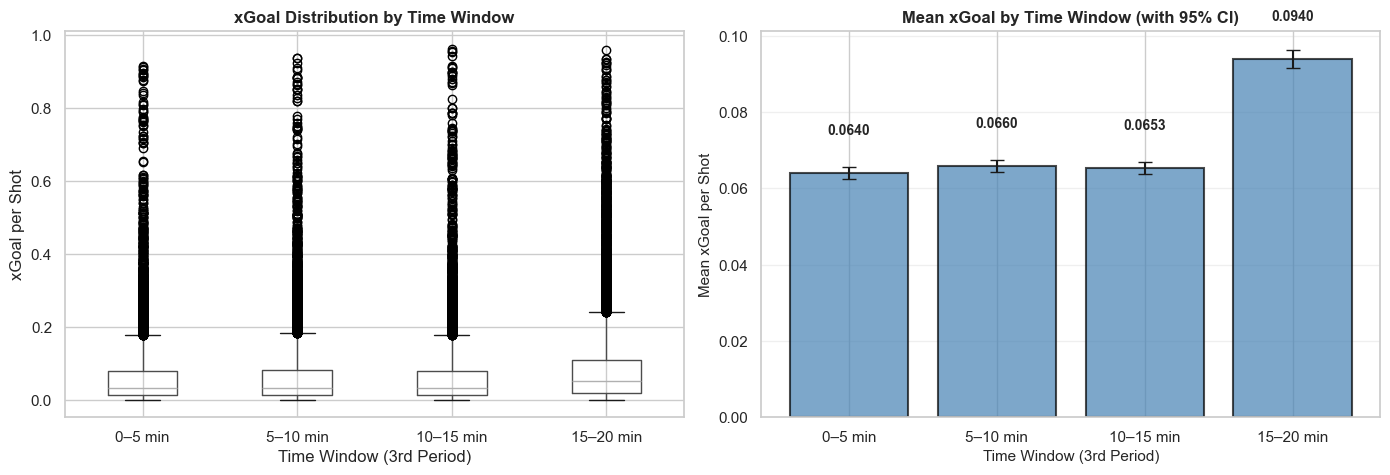

Distribution saved!


In [9]:
# Box plot by time window
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution by time window
comeback_df.boxplot(column='xGoal', by='time_bin', ax=axes[0])
axes[0].set_title('xGoal Distribution by Time Window', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Time Window (3rd Period)')
axes[0].set_ylabel('xGoal per Shot')
axes[0].get_figure().suptitle('')  # Remove auto title

# Plot 2: Mean xGoal with error bars
mean_xgoal_by_bin = comeback_df.groupby('time_bin')['xGoal'].agg(['mean', 'std', 'count'])
mean_xgoal_by_bin['se'] = mean_xgoal_by_bin['std'] / np.sqrt(mean_xgoal_by_bin['count'])

bin_positions = [0, 1, 2, 3]
axes[1].bar(bin_positions, mean_xgoal_by_bin['mean'], 
            yerr=1.96*mean_xgoal_by_bin['se'],  # 95% CI
            capsize=5, alpha=0.7, color='steelblue', edgecolor='black', linewidth=1.5)
axes[1].set_xticks(bin_positions)
axes[1].set_xticklabels(mean_xgoal_by_bin.index)
axes[1].set_ylabel('Mean xGoal per Shot', fontsize=11)
axes[1].set_xlabel('Time Window (3rd Period)', fontsize=11)
axes[1].set_title('Mean xGoal by Time Window (with 95% CI)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (idx, row) in enumerate(mean_xgoal_by_bin.iterrows()):
    axes[1].text(i, row['mean'] + 0.01, f"{row['mean']:.4f}", 
                ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / '02_xgoal_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("Distribution saved!")

### 3.3 Temporal Trajectory (Raw Data)


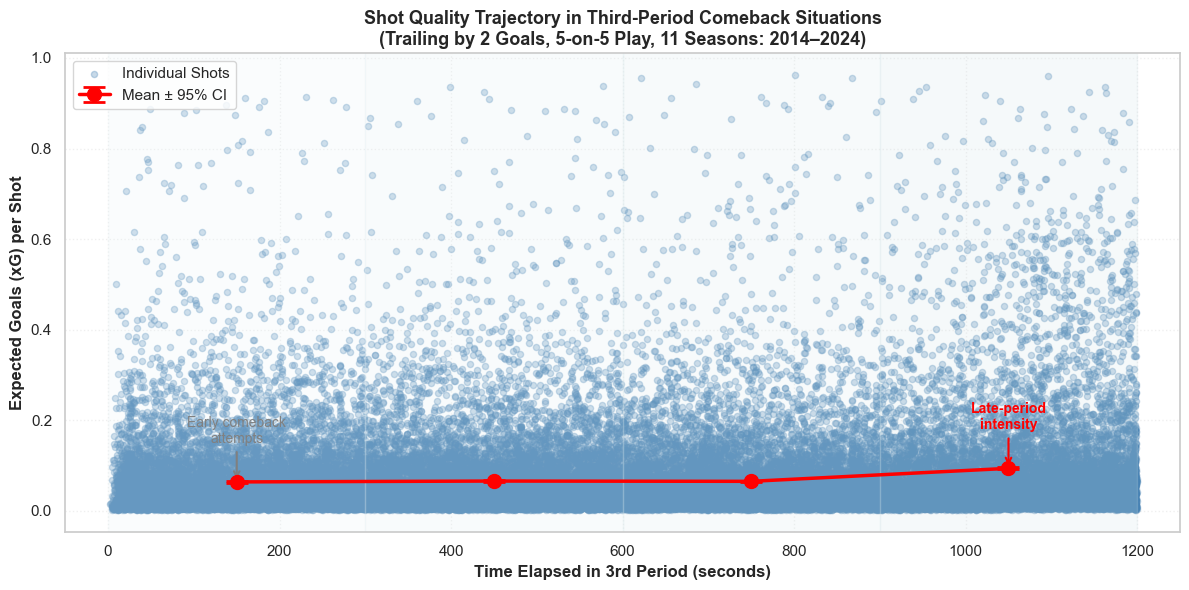

Raw trajectory plot saved!


In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

# Scatter plot
ax.scatter(comeback_df['time_elapsed_in_period'], comeback_df['xGoal'], 
          alpha=0.3, s=20, color='steelblue', label='Individual Shots')

# Binned means with 95% CI
bin_info = comeback_df.groupby('time_bin')['xGoal'].agg(['mean', 'std', 'count'])
bin_info['se'] = bin_info['std'] / np.sqrt(bin_info['count'])
bin_info['ci_lower'] = bin_info['mean'] - 1.96 * bin_info['se']
bin_info['ci_upper'] = bin_info['mean'] + 1.96 * bin_info['se']

bin_midpoints = [150, 450, 750, 1050]
ax.errorbar(bin_midpoints, bin_info['mean'], 
           yerr=[bin_info['mean'] - bin_info['ci_lower'], 
                 bin_info['ci_upper'] - bin_info['mean']],
           fmt='o-', color='red', linewidth=2.5, markersize=10, 
           capsize=8, capthick=2, label='Mean ± 95% CI', zorder=5)

# Add shaded regions for time windows
colors_alpha = ['#E8F4F8', '#E0EEF2', '#D8E8EC', '#D0E2E6']
for i, (start, end, color) in enumerate([(0, 300, colors_alpha[0]), 
                                           (300, 600, colors_alpha[1]), 
                                           (600, 900, colors_alpha[2]), 
                                           (900, 1200, colors_alpha[3])]):
    ax.axvspan(start, end, alpha=0.2, color=color)

ax.set_xlabel('Time Elapsed in 3rd Period (seconds)', fontsize=12, fontweight='bold')
ax.set_ylabel('Expected Goals (xG) per Shot', fontsize=12, fontweight='bold')
ax.set_title('Shot Quality Trajectory in Third-Period Comeback Situations\n(Trailing by 2 Goals, 5-on-5 Play, 11 Seasons: 2014–2024)', 
            fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle=':')
ax.legend(loc='upper left', fontsize=11)
ax.set_xlim(-50, 1250)

# Annotations
ax.annotate('Early comeback\nattempts', xy=(150, 0.064), xytext=(150, 0.15),
           arrowprops=dict(arrowstyle='->', color='gray', lw=1.5),
           fontsize=10, ha='center', color='gray')
ax.annotate('Late-period\nintensity', xy=(1050, 0.094), xytext=(1050, 0.18),
           arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
           fontsize=10, ha='center', color='red', fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / '03_raw_trajectory.png', dpi=300, bbox_inches='tight')
plt.show()

print("Raw trajectory plot saved!")

In [11]:
from scipy import stats

# Compare late period (15–20 min) vs. early period (0–5 min)
early = comeback_df[comeback_df['time_bin'] == '0–5 min']['xGoal']
late = comeback_df[comeback_df['time_bin'] == '15–20 min']['xGoal']

# Two-sample t-test
t_stat, p_value = stats.ttest_ind(late, early)

print("="*70)
print("HYPOTHESIS TEST: Late Period vs. Early Period")
print("="*70)
print(f"Early period (0–5 min) mean xGoal: {early.mean():.6f} (n={len(early):,})")
print(f"Late period (15–20 min) mean xGoal: {late.mean():.6f} (n={len(late):,})")
print(f"\nDifference: {late.mean() - early.mean():+.6f}")
print(f"Percentage change: {100 * (late.mean() - early.mean()) / early.mean():+.1f}%")
print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.2e}")
print(f"\nResult: {' SIGNIFICANT' if p_value < 0.05 else '✗ NOT significant'} (α = 0.05)")
print("="*70)

HYPOTHESIS TEST: Late Period vs. Early Period
Early period (0–5 min) mean xGoal: 0.064046 (n=12,006)
Late period (15–20 min) mean xGoal: 0.094007 (n=10,557)

Difference: +0.029961
Percentage change: +46.8%

t-statistic: 21.0595
p-value: 1.62e-97

Result:  SIGNIFICANT (α = 0.05)


## 4. Data Validation & Quality Checks


In [12]:
print("=== DATA QUALITY CHECKLIST ===")
print(f"No missing values in outcome (xGoal): {comeback_df['xGoal'].isna().sum() == 0}")
print(f"No missing values in predictor (time): {comeback_df['time'].isna().sum() == 0}")
print(f"xGoal in expected range [0, ~0.8]: {(comeback_df['xGoal'] >= 0).all() and (comeback_df['xGoal'] <= 1).all()}")
print(f"Time in expected range [0, 1110]: {(comeback_df['time'] >= 0).all() and (comeback_df['time'] <= 1110).all()}")
print(f"All shots from 3rd period: {(comeback_df.get('period', 3) == 3).all()}")
print(f"All shots from trailing situations (score_diff = -2): {(comeback_df['score_diff'] == -2).all()}")

print(f"\nSample size adequacy:")
print(f"  Total shots: {len(comeback_df)}")
print(f"  Unique games: {comeback_df['game_id'].nunique()}")
print(f"  Avg shots per game: {len(comeback_df) / comeback_df['game_id'].nunique():.1f}")


=== DATA QUALITY CHECKLIST ===
No missing values in outcome (xGoal): True
No missing values in predictor (time): True
xGoal in expected range [0, ~0.8]: True
Time in expected range [0, 1110]: False
All shots from 3rd period: True
All shots from trailing situations (score_diff = -2): True

Sample size adequacy:
  Total shots: 47046
  Unique games: 1373
  Avg shots per game: 34.3


## 5. Export Cleaned Data


In [13]:
# Export cleaned dataset for Phase 2
comeback_df_export = comeback_df[['game_id', 'season', 'time_elapsed_in_period', 'xGoal', 'score_diff', 'time_bin']].copy()
comeback_df_export.to_csv(RESULTS_DIR / 'comeback_clean.csv', index=False)
print(f"✓ Exported {len(comeback_df_export):,} comeback shots to comeback_clean.csv")

✓ Exported 47,046 comeback shots to comeback_clean.csv
